In [74]:
import numpy as np
from collections import Counter, defaultdict
import os
import random
from collections import defaultdict
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import time
import logging
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seeds()

In [76]:
#生成随机UMI序列的白名单（正确序列），确保最小汉明距离>=3, 长度为12, 100个, 并保存为txt文件
def generate_whitelist_umis(n_umis=100, length=12, min_hamming=3):
    """生成一个已知正确的UMI白名单，确保序列之间有足够的差异。"""
    logger.info(f"Generating a whitelist of {n_umis} UMIs (length={length})...")
    bases = ['A', 'T', 'C', 'G']
    umis = []
    
    for _ in tqdm(range(n_umis), desc="Generating Whitelist"):
        while True:
            umi = ''.join(random.choice(bases) for _ in range(length))
            if not umis or all(sum(c1 != c2 for c1, c2 in zip(umi, u)) >= min_hamming for u in umis):
                umis.append(umi)
                break
    return umis

In [77]:
#模拟错误（替换/插入/删除）
def simulate_errors(whitelist, n_reads=50000, error_rate=0.02, indel_rate=0.01):
    """
    Simulates noisy UMI reads from a whitelist, including substitution and indel errors.
    Returns a list of tuples: (noisy_umi, quality_scores, original_clean_umi)
    """
    logger.info(f"Simulating {n_reads} noisy reads...")
    noisy_data = []
    umi_length = len(whitelist[0])
    bases = ['A', 'T', 'C', 'G']

    for _ in tqdm(range(n_reads), desc="Simulating Noisy Reads"):
        original_umi = random.choice(whitelist)
        noisy_umi = list(original_umi)
        
        # 1. 替换
        for i in range(len(noisy_umi)):
            if random.random() < error_rate:
                noisy_umi[i] = random.choice([b for b in bases if b != noisy_umi[i]])
        
        # 2. Indel（插入/缺失）
        if random.random() < indel_rate:
            if random.random() < 0.5 and len(noisy_umi) > 1:
                pos = random.randint(0, len(noisy_umi) - 1)
                del noisy_umi[pos]
            else: # Insertion
                pos = random.randint(0, len(noisy_umi))
                noisy_umi.insert(pos, random.choice(bases))

        noisy_umi_str = "".join(noisy_umi)
        
        # 3. 模拟质量分数（简化）
        # 在两端出现低质量的概率更高
        qualities = []
        for i in range(len(noisy_umi_str)):
            if i < 2 or i > len(noisy_umi_str) - 3:
                qualities.append(random.randint(10, 25))
            else:
                qualities.append(random.randint(30, 40))

        noisy_data.append((noisy_umi_str, qualities, original_umi))
    return noisy_data

In [78]:
# 模拟PCR扩增和测序
def simulate_pcr_and_sequencing(
    whitelist, 
    n_reads_to_sequence=50000, 
    n_initial_molecules=5000,
    pcr_cycles=12, 
    pcr_efficiency=0.85,
    pcr_error_rate=1e-4,
    seq_error_rate=0.005,
    indel_rate=0.01
):
    """
    模拟一个真实的UMI工作流，包括PCR扩增和测序，以生成带噪数据。
    """
    logger.info(f"Simulating PCR & Sequencing for {n_reads_to_sequence} final reads...")
    
    umi_length = len(whitelist[0])
    bases = ['A', 'T', 'C', 'G']
    
    #步骤 1: 初始分子捕获
    initial_molecules = random.choices(whitelist, k=n_initial_molecules)
    
    #步骤 2: PCR 扩增 (引入PCR错误)
    final_pcr_pool = []
    for original_umi in tqdm(initial_molecules, desc="Simulating PCR Families"):
        family = [list(original_umi)]
        for _ in range(pcr_cycles):
            newly_synthesized = []
            for template in family:
                if random.random() < pcr_efficiency:
                    new_strand = list(template)
                    for i in range(len(new_strand)):
                        if random.random() < pcr_error_rate:
                            new_strand[i] = random.choice([b for b in bases if b != new_strand[i]])
                    newly_synthesized.append(new_strand)
            family.extend(newly_synthesized)
            if len(family) > 2000: family = random.sample(family, 2000)

        final_pcr_pool.extend([("".join(umi), original_umi) for umi in family])
    logger.info(f"PCR simulation produced a pool of {len(final_pcr_pool)} molecules.")
    
    # 步骤 3: 测序 (引入测序错误)
    if not final_pcr_pool: return []
    num_to_sample = min(n_reads_to_sequence, len(final_pcr_pool))
    sequencing_candidates = random.sample(final_pcr_pool, k=num_to_sample)
    
    final_noisy_data = []
    for pcr_product, original_umi in tqdm(sequencing_candidates, desc="Simulating Sequencing"):
        sequenced_read = list(pcr_product)
        # 测序替换错误
        for i in range(len(sequenced_read)):
            if random.random() < seq_error_rate:
                sequenced_read[i] = random.choice([b for b in bases if b != sequenced_read[i]])
        # 测序Indel错误
        if random.random() < indel_rate:
            if random.random() < 0.5 and len(sequenced_read) > 1: del sequenced_read[random.randint(0, len(sequenced_read) - 1)]
            else: sequenced_read.insert(random.randint(0, len(sequenced_read)), random.choice(bases))
        
        noisy_umi_str = "".join(sequenced_read)
        # 模拟质量分数
        qualities = [random.randint(10, 25) if (i < 2 or i > len(noisy_umi_str) - 3) else random.randint(30, 40) for i in range(len(noisy_umi_str))]
        final_noisy_data.append((noisy_umi_str, qualities, original_umi))
        
    return final_noisy_data

In [79]:
# 阶段一：快速预校正，使用汉明距离为1的索引进行校正
def build_1_hamming_index(whitelist):
    """用于快速查找汉明距离为1的变体。"""
    logger.info("Building 1-Hamming distance index...")
    index = {}
    bases = ['A', 'T', 'C', 'G']
    for umi in tqdm(whitelist, desc="Building Index"):
        for i in range(len(umi)):
            original_char = umi[i]
            for base in bases:
                if base != original_char:
                    variant = umi[:i] + base + umi[i+1:]
                    # 如果一个变体可能来自多个白名单UMI，标记为歧义 (None)
                    index[variant] = umi if variant not in index else None
    return index

def stage1_fast_correction(noisy_data_with_indices, whitelist, hamming_index):
    """阶段一：使用精确匹配和汉明索引进行快速校正。"""
    logger.info("Running Stage 1: Fast Pre-correction...")
    whitelist_set = set(whitelist)
    corrected_results = {}
    remaining_data = []

    for i, umi, qual, original in tqdm(noisy_data_with_indices, desc="Stage 1"):
        if umi in whitelist_set:
            corrected_results[i] = (umi, original, "Exact Match")
        elif umi in hamming_index and hamming_index[umi] is not None:
            corrected_results[i] = (hamming_index[umi], original, "1-Hamming")
        else:
            remaining_data.append((i, umi, qual, original)) 
            
    return corrected_results, remaining_data

# 阶段三：使用Smith-Waterman算法处理长度异常的序列
def smith_waterman(seq1, seq2, match=2, mismatch=-1, gap=-2):
    m, n = len(seq1), len(seq2)
    score = np.zeros((m+1, n+1))
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            sc = match if seq1[i-1] == seq2[j-1] else mismatch
            score[i,j] = max(0, score[i-1,j-1] + sc, score[i-1,j] + gap, score[i,j-1] + gap)
    return np.max(score)

def stage3_indel_correction(variable_length_data_with_indices, whitelist):
    logger.info("Running Stage 3: Targeted Indel Correction...")
    corrected_results = {}
    umi_length = len(whitelist[0])
    score_threshold = umi_length * 2 * 0.7 

    for i, umi, qual, original in tqdm(variable_length_data_with_indices, desc="Stage 3 (Indels)"):
        scores = [smith_waterman(umi, wl_umi) for wl_umi in whitelist]
        best_score_idx = np.argmax(scores)
        
        if scores[best_score_idx] >= score_threshold:
            corrected_results[i] = (whitelist[best_score_idx], original, "Indel-Corrected")
        else:
            corrected_results[i] = (None, original, "Indel-Uncorrected")
            
    return corrected_results

# 阶段二：使用深度学习模型进行校正
def one_hot_encode(umi, umi_length):
    base_map = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
    encoded = np.zeros((umi_length, 4), dtype=np.float32)
    for i, base in enumerate(umi):
        if i < umi_length and base in base_map:
            encoded[i, base_map[base]] = 1
    return encoded.flatten()

class DenoisingConvAE(nn.Module):
    """1D Convolutional Denoising Autoencoder for UMI sequences."""
    def __init__(self, seq_len, n_features=4):
        super().__init__()
        self.seq_len, self.n_features = seq_len, n_features
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(16),
            nn.Conv1d(16, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(32),
            nn.Flatten(), nn.Linear(32 * seq_len, 32)) 
        self.decoder = nn.Sequential(
            nn.Linear(32, 32 * seq_len), nn.ReLU(),
            nn.Unflatten(1, (32, seq_len)),
            nn.ConvTranspose1d(32, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(16),
            nn.ConvTranspose1d(16, n_features, 3, padding=1), nn.Softmax(dim=1))

    def forward(self, x):
        x = x.reshape(-1, self.n_features, self.seq_len)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.reshape(-1, self.n_features * self.seq_len)
    
    def encode(self, x):
        with torch.no_grad():
            x = x.reshape(-1, self.n_features, self.seq_len)
            return self.encoder(x)

def train_autoencoder(model_class, whitelist, epochs=30, batch_size=128, num_samples=20000, test_size=0.2):
    logger.info("Starting Classifier training with Validation Set...")
    
    noisy_data = simulate_errors(whitelist, n_reads=num_samples, error_rate=0.05, indel_rate=0)
    
    # 输入(X): one-hot编码的带噪UMI
    umi_length = len(whitelist[0])
    X = np.array([one_hot_encode(u, umi_length) for u,_,_ in noisy_data])
    
    # 目标(y): 无噪UMI在白名单中的索引（类别标签）
    whitelist_map = {umi: i for i, umi in enumerate(whitelist)}
    y = np.array([whitelist_map[o] for _,_,o in noisy_data])
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y 
    )
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)
    
    train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # 训练
    input_dim = umi_length * 4
    num_classes = len(whitelist)
    model = model_class(input_dim, num_classes) 
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}

    logger.info(f"Training on {len(X_train)} samples, validating on {len(X_val)} samples.")
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for noisy_batch, clean_labels_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(noisy_batch)
            loss = criterion(outputs, clean_labels_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            _, predicted = torch.max(val_outputs.data, 1)
            total = y_val_t.size(0)
            correct = (predicted == y_val_t).sum().item()
            val_accuracy = 100 * correct / total
            
            history['val_loss'].append(val_loss)
            history['val_accuracy'].append(val_accuracy)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            logger.info(f"Epoch [{epoch+1: >3}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")
    
    logger.info("Classifier training finished.")
    return model, history


def stage2_dl_correction(remaining_data_with_indices, model, whitelist):
    logger.info("Running Stage 2: Deep Learning Correction...")
    
    model.eval()
    umi_length = len(whitelist[0])
    
    corrected_results = {}
    for i, umi, qual, original in tqdm(remaining_data_with_indices, desc="Stage 2 (DL)"):
        # 1. 将单个UMI编码为张量
        umi_tensor = torch.tensor(one_hot_encode(umi, umi_length), dtype=torch.float32).unsqueeze(0)
        
        # 2. 使用模型直接预测最可能的类别（即白名单中的索引）
        with torch.no_grad():
            output = model(umi_tensor)
            _, predicted_idx = torch.max(output.data, 1)
            best_match_idx = predicted_idx.item()
        
        # 3. 从白名单中获取校正结果
        corrected_results[i] = (whitelist[best_match_idx], original, "DL-Corrected")
        
    return corrected_results

class UMIClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def run_optimal_pipeline(noisy_data, whitelist):
    """执行完整的三阶段UMI校正。"""
    umi_length = len(whitelist[0])
    logger.info(" Starting Optimal UMI Correction Pipeline ")
    
    # 按长度分拣数据，并保留原始索引i
    normal_length_data = []
    variable_length_data = []
    for i, data_point in enumerate(noisy_data):
        if len(data_point[0]) == umi_length:
            normal_length_data.append((i, *data_point))
        else:
            variable_length_data.append((i, *data_point))
            
    logger.info(f"Sorted data: {len(normal_length_data)} normal length, {len(variable_length_data)} variable length.")

    all_corrected_results = {}
    start_time = time.time()
    
    # 阶段一: Indel 校正
    if variable_length_data:
        all_corrected_results.update(stage3_indel_correction(variable_length_data, whitelist))
    
    # 阶段二: 快速预校正
    if normal_length_data:
        hamming_index = build_1_hamming_index(whitelist)
        stage1_corrected, stage1_remaining = stage1_fast_correction(normal_length_data, whitelist, hamming_index)
        all_corrected_results.update(stage1_corrected)
    
    # 阶段三: 深度学习校正
    if stage1_remaining:
        trained_model, training_history = train_autoencoder(UMIClassifier, whitelist)
        all_corrected_results.update(stage2_dl_correction(stage1_remaining, trained_model, whitelist))

    pipeline_time = time.time() - start_time
    logger.info(f" Pipeline finished in {pipeline_time:.2f} seconds ")
    
    
    # 重新排序，保持与原始输入一致
    final_results = [None] * len(noisy_data)
    for i in range(len(noisy_data)):
        if i in all_corrected_results:
            final_results[i] = all_corrected_results[i]
        else:
            final_results[i] = (None, noisy_data[i][2], "Uncorrected")
            
    return final_results, training_history if 'training_history' in locals() else None

In [80]:
#  可视化验证校正结果

def validate_and_visualize(final_results, noisy_data, whitelist, training_history=None):
    """计算指标并生成可视化图表来证验证校正效果。"""
    
    #  1. 计算核心指标 
    original_umis = [item[2] for item in noisy_data]
    corrected_umis = [item[0] for item in final_results]
    
    accuracy = accuracy_score(
        [o for i, o in enumerate(original_umis) if corrected_umis[i] is not None],
        [c for c in corrected_umis if c is not None]
    )
    
    total_reads = len(noisy_data)
    corrected_count = total_reads - corrected_umis.count(None)
    recovery_rate = corrected_count / total_reads

    logger.info(" Validation Metrics ")
    logger.info(f"Recovery Rate (能被校正的比例): {recovery_rate:.2%}")
    logger.info(f"Accuracy (在被校正的部分中，校对正确的比例): {accuracy:.2%}")

    #  2. 可视化校正前后的汉明距离分布 
    pre_correction_distances = []
    umi_len = len(whitelist[0])
    for noisy, _, original in noisy_data:
        if len(noisy) == umi_len:
            pre_correction_distances.append(sum(c1 != c2 for c1, c2 in zip(noisy, original)))

    # 计算校正后，校正结果与其真实来源的汉明距离
    post_correction_distances = []
    for corrected, original, _ in final_results:
        if corrected and len(corrected) == umi_len:
            post_correction_distances.append(sum(c1 != c2 for c1, c2 in zip(corrected, original)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.countplot(x=pre_correction_distances, ax=ax1, palette='viridis')
    ax1.set_title('Before Correction: Hamming Distance to True UMI', fontsize=16)
    ax1.set_xlabel('Hamming Distance', fontsize=12)
    ax1.set_ylabel('Number of Reads', fontsize=12)
    ax1.set_yscale('log')
    
    sns.countplot(x=post_correction_distances, ax=ax2, palette='magma')
    ax2.set_title('After Correction: Hamming Distance to True UMI', fontsize=16)
    ax2.set_xlabel('Hamming Distance', fontsize=12)
    ax2.set_ylabel('Number of Reads', fontsize=12)
    ax2.set_yscale('log')

    fig.suptitle('Effectiveness of UMI Correction Pipeline', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

    #  3. 可视化UMI种类变化 
    pre_correction_counts = Counter([item[0] for item in noisy_data])
    post_correction_counts = Counter(filter(None, corrected_umis))

    fig, ax = plt.subplots(figsize=(10, 6))
    bar_width = 0.35
    labels = ['Unique UMI Species']
    x = np.arange(len(labels))

    ax.bar(x - bar_width/2, [len(pre_correction_counts)], bar_width, label='Before Correction', color='skyblue')
    ax.bar(x + bar_width/2, [len(post_correction_counts)], bar_width, label='After Correction', color='salmon')

    ax.set_ylabel('Number of Unique UMIs', fontsize=12)
    ax.set_title('Reduction in UMI Complexity', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    for i, count in enumerate([len(pre_correction_counts), len(post_correction_counts)]):
        ax.text(x[0] + (i-0.5)*bar_width, count + 50, str(count), ha='center', va='bottom', fontsize=12)

    #  4. 可视化训练过程 
    if training_history:
        fig, ax1 = plt.subplots(figsize=(12, 6))

        color = 'tab:red'
        ax1.set_xlabel('Epochs', fontsize=12)
        ax1.set_ylabel('Loss', color=color, fontsize=12)
        ax1.plot(training_history['train_loss'], color=color, label='Train Loss')
        ax1.plot(training_history['val_loss'], color=color, linestyle='--', label='Validation Loss')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Accuracy (%)', color=color, fontsize=12)
        ax2.plot(training_history['val_accuracy'], color=color, linestyle='-.', label='Validation Accuracy')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.legend(loc='upper right')
        
        fig.tight_layout()
        plt.title('Training and Validation Metrics Over Epochs', fontsize=16)
        plt.show()
    plt.show()

2025-06-19 21:34:11,028 - INFO - Generating a whitelist of 100 UMIs (length=12)...


Generating Whitelist:   0%|          | 0/100 [00:00<?, ?it/s]

2025-06-19 21:34:11,039 - INFO - Simulating PCR & Sequencing for 10000 final reads...


Simulating PCR Families:   0%|          | 0/1000 [00:00<?, ?it/s]

2025-06-19 21:34:11,433 - INFO - PCR simulation produced a pool of 469785 molecules.


...

2025-06-19 21:34:12,379 - INFO - Starting Classifier training with Validation Set...
2025-06-19 21:34:12,380 - INFO - Simulating 20000 noisy reads...


Simulating Noisy Reads:   0%|          | 0/20000 [00:00<?, ?it/s]

2025-06-19 21:34:12,657 - INFO - Training on 16000 samples, validating on 4000 samples.
2025-06-19 21:34:13,151 - INFO - Epoch [  1/30], Train Loss: 1.3872, Val Loss: 0.1524, Val Accuracy: 99.70%
2025-06-19 21:34:14,871 - INFO - Epoch [  5/30], Train Loss: 0.0292, Val Loss: 0.0144, Val Accuracy: 99.88%
2025-06-19 21:34:16,718 - INFO - Epoch [ 10/30], Train Loss: 0.0100, Val Loss: 0.0078, Val Accuracy: 99.90%
2025-06-19 21:34:18,549 - INFO - Epoch [ 15/30], Train Loss: 0.0055, Val Loss: 0.0055, Val Accuracy: 99.92%
2025-06-19 21:34:20,421 - INFO - Epoch [ 20/30], Train Loss: 0.0036, Val Loss: 0.0050, Val Accuracy: 99.95%
2025-06-19 21:34:22,331 - INFO - Epoch [ 25/30], Train Loss: 0.0058, Val Loss: 0.0064, Val Accuracy: 99.83%
2025-06-19 21:34:24,142 - INFO - Epoch [ 30/30], Train Loss: 0.0032, Val Loss: 0.0065, Val Accuracy: 99.85%
2025-06-19 21:34:24,144 - INFO - Classifier training finished.
2025-06-19 21:34:24,146 - INFO - Running Stage 2: Deep Learning Correction...


Stage 2 (DL):   0%|          | 0/18 [00:00<?, ?it/s]

2025-06-19 21:34:24,159 - INFO -  Pipeline finished in 12.59 seconds 
2025-06-19 21:34:24,186 - INFO -  Validation Metrics 
2025-06-19 21:34:24,187 - INFO - Recovery Rate (能被校正的比例): 100.00%
2025-06-19 21:34:24,187 - INFO - Accuracy (在被校正的部分中，校对正确的比例): 100.00%
2025-06-19 21:34:24,238 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33408\767905190.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=pre_correction_distances, ax=ax1, palette='viridis')
2025-06-19 21:34:24,248 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate

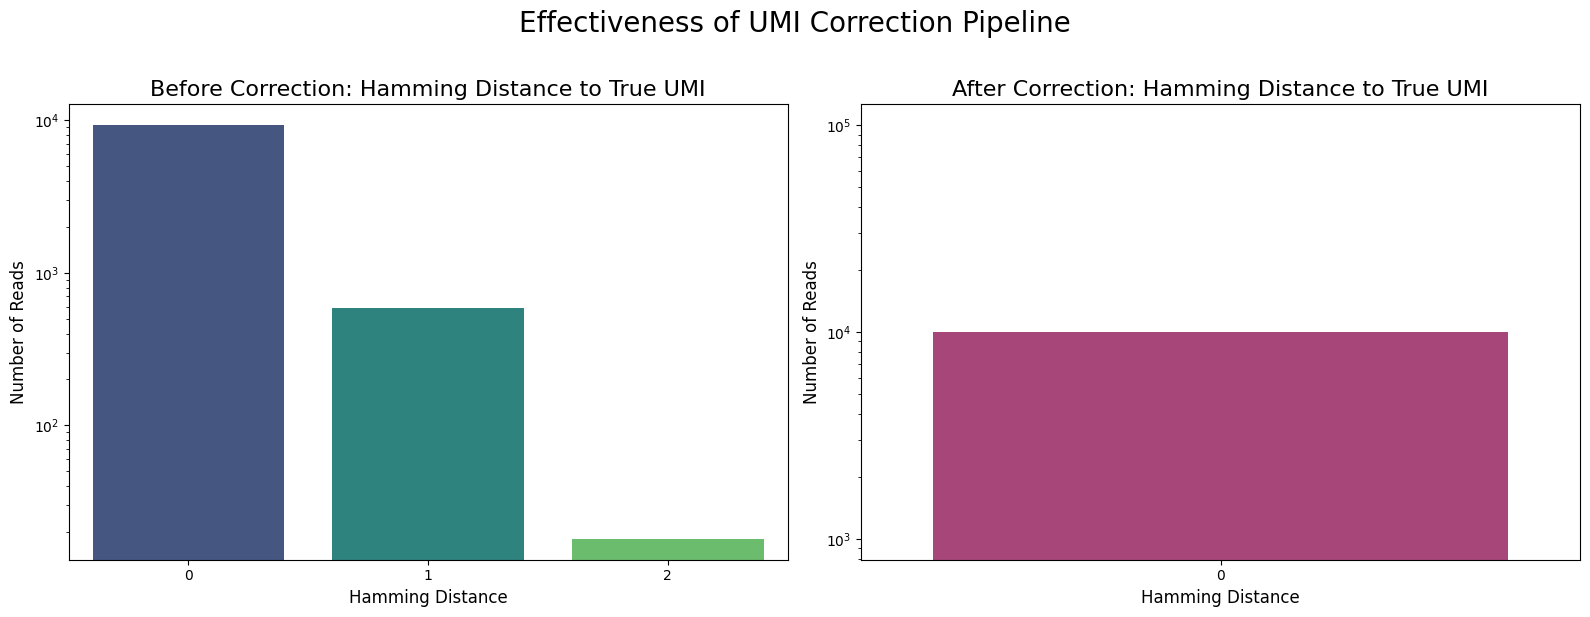

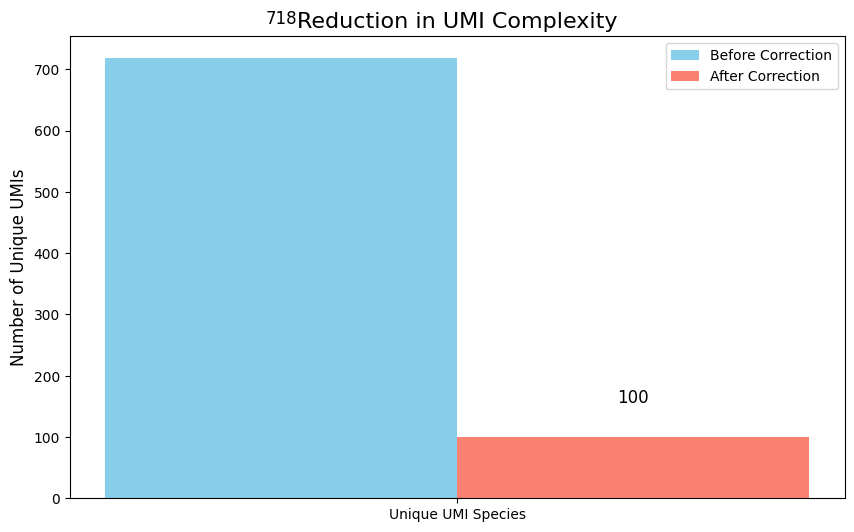

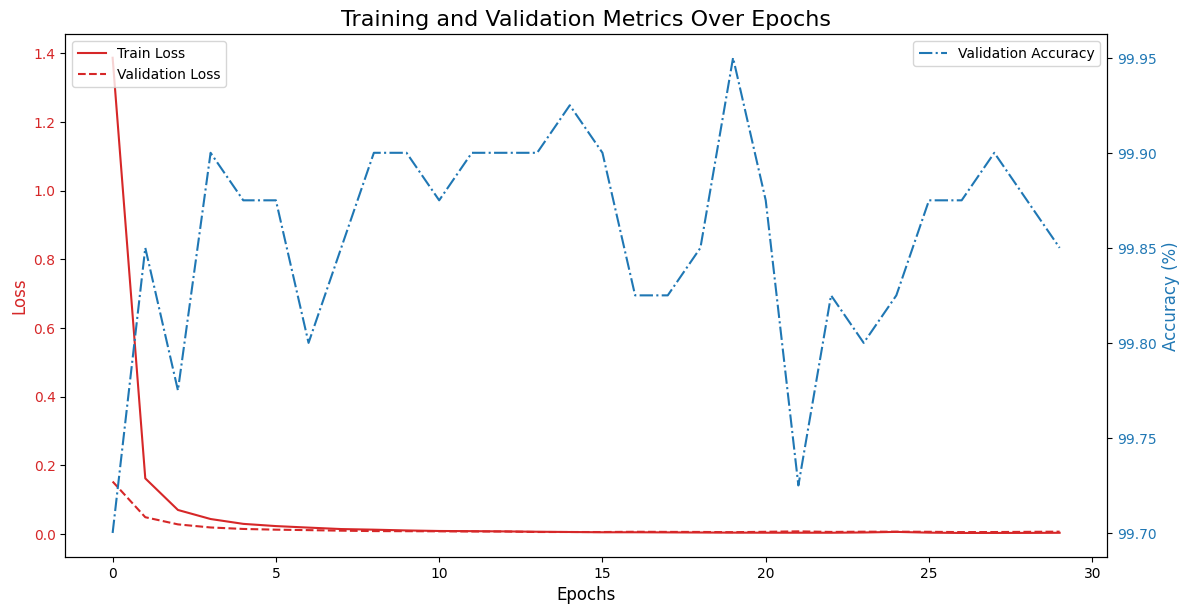

In [81]:
# Main

# 1. 生成数据
whitelist = generate_whitelist_umis(n_umis=100, length=12)
noisy_data = simulate_pcr_and_sequencing(
    whitelist, 
    n_reads_to_sequence=10000, 
    n_initial_molecules=1000,
    pcr_cycles=10,
    seq_error_rate=0.005,
    indel_rate=0.01
)
    
# 2. 校正过程
final_results, training_history = run_optimal_pipeline(noisy_data, whitelist)
    
# 3. 验证并可视化结果
validate_and_visualize(final_results, noisy_data, whitelist, training_history) 